# Control predictivo adaptativo

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import scipy as sc
from scipy.signal import lfilter


In [78]:
def calcularPolinomiosPredictivo(A,Bp,d):
    # Calculo de polinomios del predictor
    F = lfilter([1], A, np.r_[1, np.zeros(d-1)])
    Gp = np.r_[1,np.zeros(len(A)+d-2)] - np.polymul(A,F) 
    G = Gp[d:]
    FBp = np.polymul(F,Bp)

    #print("F =", F)
    #print("G =", G)  
    #print(f'Prueba ec Diofantina: AF+q^(-d)G ={np.polymul(A,F)+np.r_[np.zeros(d),G]}')
    return F,G,FBp

## Simulación del control predictivo adaptativo directo

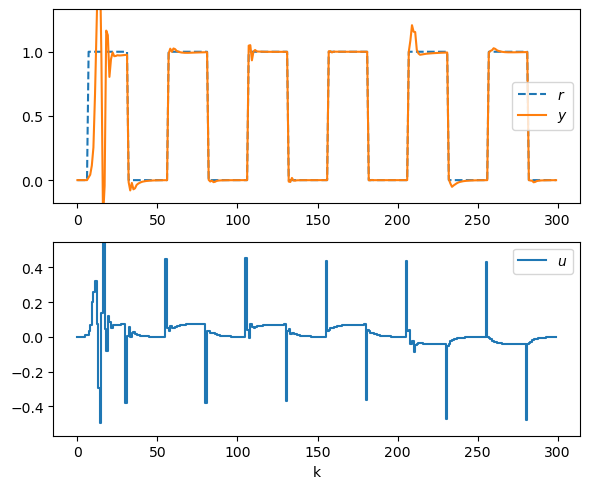

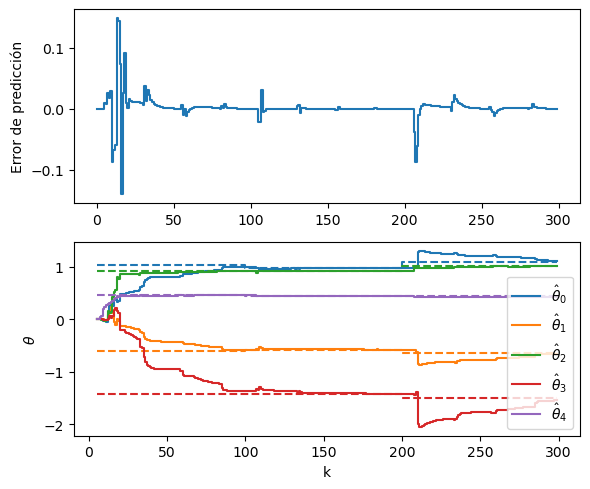

In [203]:
def simularControlPredictivoPonderadoAdaptativo(A, Bp, d, r, v=None, lambda_b0 = 0, alpha=0.95, deltaA=None, deltaB=None, umax=None, plot=True, title=None):
    """
    Simula un controlador predictivo ponderado adaptativo (RLS) para un modelo ARX.

    Entradas:
      - A: vector de coeficientes del polinomio A (mónico) [1, a1, a2, ...]
      - Bp: vector de coeficientes del polinomio B (incluye b0,b1,...)
      - d: delay (nk) en muestras
      - r: referencia (vector de longitud N)
      - v: perturbación aditiva sobre la acción de control (opcional)
      - lambda_b0: factor de ponderación aplicado a b0 (para regularización)
      - alpha: factor de olvido del RLS (0<alpha<=1)
      - deltaA, deltaB: vectores de variación en A y Bp aplicados on-line (opcional)
      - umax: saturación absoluta de la acción de control (opcional)
      - plot: si True dibuja resultados al final
      - title: título opcional para la figura

    Salidas:
      - y: salida simulada
      - u: acción de control usada (no saturada)
    """

    # copias locales del modelo (se actualizan si se pasan deltaA/deltaB)
    A_ = A.copy()
    Bp_ = Bp.copy()

    na = len(A)          # número de coeficientes de A
    nb = len(Bp)         # número de coeficientes de Bp
    nu = (nb-1) + (d-1)  # número de términos de control en el regresor
    npar = na - 1 + nu + 1   # cantidad de parámetros que estima el RLS (salidas pasadas + controles + término extra)

    # señales y buffers
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)      # acción de control calculada por la ley
    uv = np.zeros(N)     # acción de control efectivamente aplicada (u + v, y saturación)
    y = np.zeros(N)      # salida de la planta
    err = np.zeros(N)    # vector donde se guarda el error de identificación (desplazado)

    # inicialización RLS para estimación de parámetros del controlador
    theta_hat = np.zeros(npar)      # estimación actual de parámetros
    theta_hat[-1] = 0.01            # pequeña semilla en último parámetro para evitar singularidades
    theta_hist = []                 # historial de theta (para mostrar)
    theta_real_hist = []            # historial de theta "teórico" basado en el modelo
    P = 100 * np.eye(npar)          # matriz de covarianza inicial (gran incertidumbre)

    # bucle de simulación: arrancamos en índice suficiente para disponer de históricos
    for kk in range(npar, N):
        # --- Construcción del vector de regresores para la etapa de identificación (phiC_est)
        # contiene: -y[k-d], -y[k-d-1], ..., -u[k-1-d], ..., y[k] + lambda_b0*u[k-d]
        phiC_est = np.r_[
            -y[kk-d:kk-d-na+1:-1],                 # salidas pasadas (con signo -)
            -u[kk-1-d:kk-1-d-nu:-1],               # controles pasados (con signo -)
            y[kk] + lambda_b0 * u[kk-d]            # término que incluye la salida actual y la ponderación
        ]

        # --- Error de identificación (u medido menos u predicho por el estimador)
        # se guarda desplazado en err para alinear tiempos (kk-d)
        err[kk-d] = u[kk-d] - phiC_est @ theta_hat

        # --- Actualización RLS (ganancia K, actualización theta_hat y P)
        K = (P @ phiC_est) / (alpha + phiC_est.T @ P @ phiC_est)   # ganancia RLS
        theta_hat = theta_hat + K * err[kk-d]                    # nueva estimación
        P = (P - np.outer(K, phiC_est) @ P) / alpha              # actualización de covarianza
        theta_hist.append(theta_hat.copy())

        # --- Construcción del vector de regresores para la ley de control (phiC)
        # contiene: -y[k], -y[k-1], ..., -u[k-1], ..., referencia futura r[k+d]
        phiC = np.r_[
            -y[kk:kk-na+1:-1],                         # salidas pasadas (con signo -)
            -u[kk-1:kk-1-nu:-1],                       # controles pasados (con signo -)
            (r[kk+d] if kk < N - d else r[-1])         # referencia a futuro (o último valor si no existe)
        ]

        # --- Ley de control: acción calculada con los parámetros estimados
        u[kk] = phiC @ theta_hat

        # --- Aplicación saturación opcional
        if umax is not None and np.abs(u[kk]) > umax:
            u[kk] = np.sign(u[kk]) * umax

        # --- Aplicación de perturbación sobre la acción opcional
        uv[kk] = u[kk] + (v[kk] if v is not None else 0)

        # --- Si se proveen variaciones del modelo, aplicarlas on-line
        if deltaA is not None:
            A_[1:] = A[1:] * (1 + deltaA[kk])   # modifica solo los coeficientes dinámicos
        if deltaB is not None:
            Bp_ = Bp * (1 + deltaB[kk])         # modifica Bp completo

        # --- Cálculo de theta "real" teórico para monitorización (opcional)
        lambda_ = lambda_b0 * Bp_[0]
        F, G, FBp = calcularPolinomiosPredictivo(A_, Bp_, d)
        theta_real = Bp_[0] / (Bp_[0]**2 + lambda_) * np.r_[G, FBp[1:], 1]
        theta_real_hist.append(theta_real.copy())

        # --- Simulación de la planta (modelo ARX) para obtener y[k+1]
        y_AR = np.dot(-A_[1:], y[kk:kk-na+1:-1])           # parte autoregresiva
        y_X = np.dot(Bp_, uv[kk-d+1:kk-d+1-nb:-1])        # parte debida a la entrada con delay
        if kk < N - 1:
            y[kk+1] = y_AR + y_X

    # --- Ploteo de resultados (opcional)
    if plot:
        plt.figure(figsize=(6,5))
        plt.subplot(211)
        plt.plot(k, r, '--', label='$r$')
        plt.plot(k, y, label='$y$')
        ymin, ymax = np.min(y[int(N/3):]), np.max(y[int(N/3):])
        plt.ylim(ymin - 0.1*(ymax-ymin), ymax + 0.1*(ymax-ymin)); 
        if title is not None:
            plt.title(title)
        plt.legend()

        plt.subplot(212)
        plt.step(k, u, label='$u$', where='post')
        umin, umax = np.min(u[int(N/3):]), np.max(u[int(N/3):])
        plt.ylim(umin - 0.1*(umax-umin), umax + 0.1*(umax-umin));
        plt.legend()
        plt.xlabel('k')
        plt.tight_layout()
        plt.show()

        # mostrar evolución de theta y error de predicción
        theta_hist = np.array(theta_hist)
        theta_real_hist = np.array(theta_real_hist)
        plt.figure(figsize=(6,5))
        plt.subplot(211)
        plt.step(k, err, where='post')
        if title is not None:
            plt.title('Evolución de la estimación')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        for idx_n in range(npar):
            color = colors[idx_n % len(colors)]
            plt.step(k[-len(theta_hist):], theta_hist[:, idx_n], color=color, label=f"$\\hat{{\\theta}}_{idx_n}$", where='post')
            plt.step(k[-len(theta_real_hist):], theta_real_hist[:, idx_n], '--', color=color, where='post')
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return y, u


A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, -.9]
d = 2

N = 300
k = np.arange(N)
r = 0.5 * (sc.signal.square(2*np.pi * k / 50 - np.pi/4) + 1)

deltaA = np.zeros(N)
deltaB = np.zeros(N)
deltaA[int(N*2/3):] = 0.05
deltaB[int(N*1/3):] = 0.05

_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,lambda_b0=0,deltaA=deltaA,deltaB=deltaB, umax=0.6)

## Simulación sobre planta con cero negativo

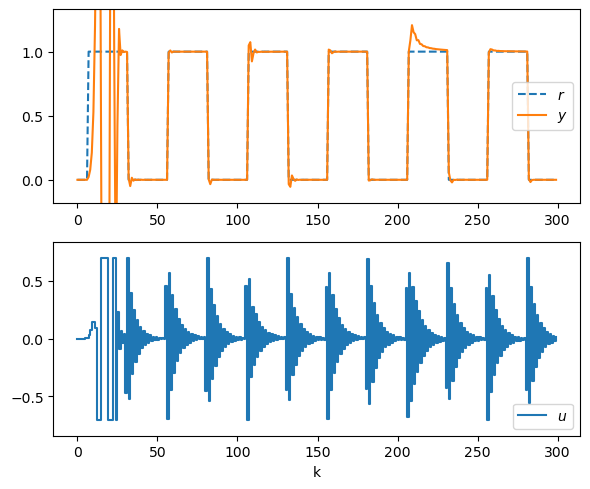

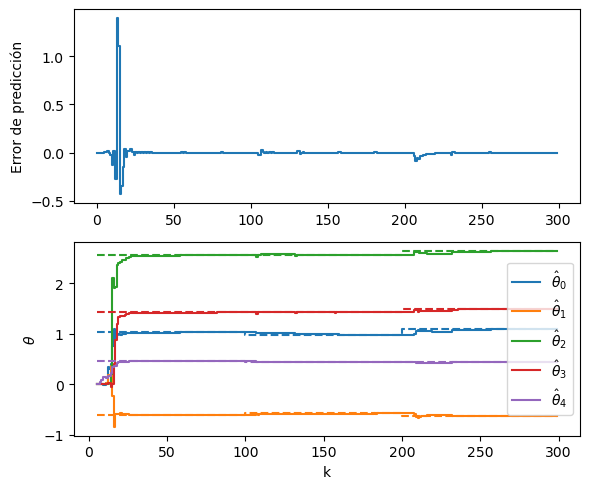

In [204]:
A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, .9]
d = 2

N = 300
k = np.arange(N)
r = 0.5 * (sc.signal.square(2*np.pi * k / 50 - np.pi/4) + 1)

deltaA = np.zeros(N)
deltaB = np.zeros(N)
deltaA[int(N*2/3):] = 0.05
deltaB[int(N*1/3):] = 0.05

_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,deltaA=deltaA,deltaB=deltaB,umax=0.7)

## Simulación del control predictivo ponderado adaptativo directo

Según lo visto en la simulación anterior, es necesario ponderar para limitar la acción de control

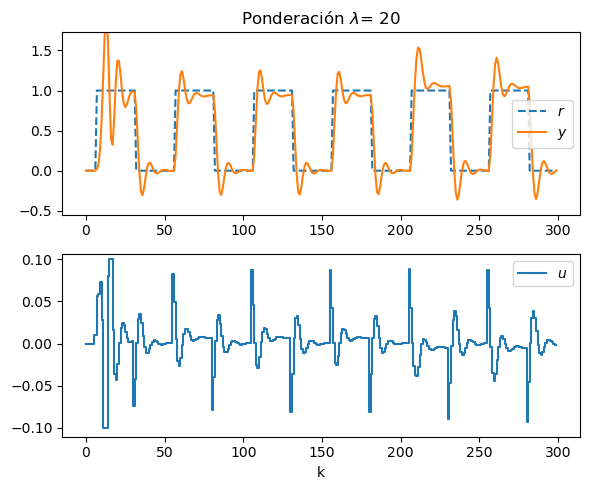

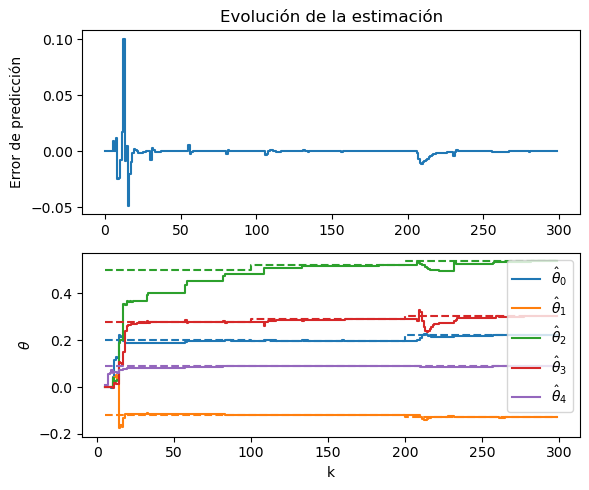

In [205]:
lambda_ = 20
lambda_b0 = lambda_ / Bp[0]
_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,alpha=0.95,lambda_b0=lambda_b0,deltaA=deltaA,deltaB=deltaB, title=f'Ponderación $\lambda$= {lambda_}',umax=0.1)

## Control predictivo ponderado por polinomios adaptativo

Polinomio P=[ 1.     -1.3981  0.4976]
Polinomio R=[ 1. -1.  0.]
na=3  nb=2  nu=2   nuf=2
Estimando na-1+nu+nuf+1=7 parámetros del control


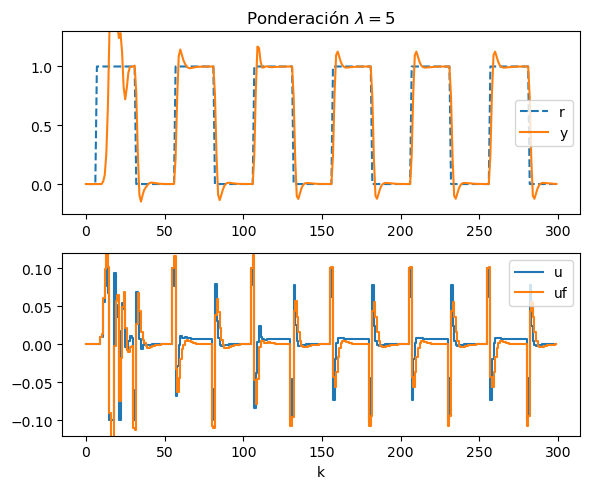

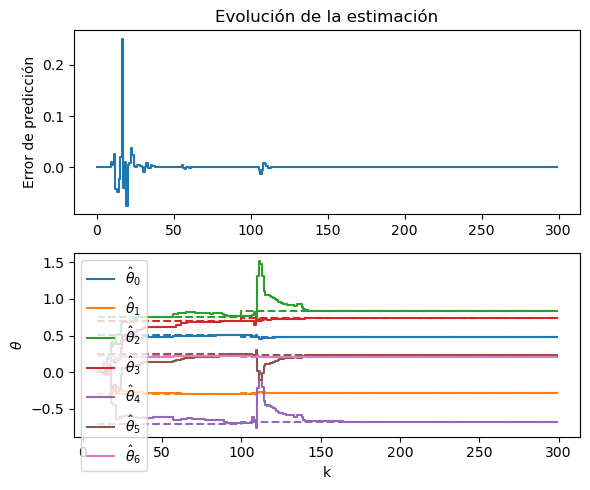

In [206]:
def simularControlPredictivoPonderadoPolinomiosAdaptativo(A, Bp, d, r, R=np.r_[1], P=np.r_[1],
                                                          lambda_b0 = 0, alpha=0.95,
                                                          deltaA=None, deltaB=None, umax=None,
                                                          plot=True, title=None):
    """
    Control predictivo ponderado por polinomios (versión adaptativa, RLS).

    Descripción breve:
      Simula un controlador predictivo adaptativo donde la ley de control se
      estima on-line por RLS y la acción de control puede ser filtrada mediante
      polinomios R (numerador) y P (denominador). Soporta perturbaciones
      sobre el modelo (deltaA, deltaB) aplicadas on-line y saturación de u.

    Entradas:
      - A: vector monico del polinomio A (ej. [1, a1, a2, ...])
      - Bp: vector del numerador B (incluye b0,b1,...)
      - d: delay (nk) en muestras
      - r: referencia (vector de longitud N)
      - R: polinomio R (numerador del filtro de ponderación de u)
      - P: polinomio P (denominador del filtro de ponderación de u)
      - lambda_b0: factor de ponderación (lambda/b0) (regularización en cálculo teórico)
      - alpha: factor de olvido para RLS (0<alpha<=1)
      - deltaA, deltaB: vectores de cambio relativo de A y Bp aplicados en tiempo (opcional)
      - umax: saturación absoluta de la acción de control (opcional)
      - plot: si True muestra gráficas finales
      - title: título opcional para las figuras

    Salidas:
      - y: salida simulada de la planta
      - u: acción de control calculada (antes del posible filtrado uf)
    """

    # copias locales del modelo (se pueden modificar on-line si se proveen deltaA/deltaB)
    A_ = A.copy()
    Bp_ = Bp.copy()

    # órdenes y dimensiones:
    na = len(A)              # número de coeficientes de A (incluye el 1 monico)
    nb = len(Bp)             # número de coeficientes de Bp (incluye b0)
    # nu: número de términos de control considerados en el regresor (incluye retrasos)
    nu = np.max((nb-1 + d-1, len(R)-1))
    nuf = len(P) - 1         # número de términos de uf (filtrado)
    # npar: parámetros que estima el RLS (salidas pasadas + controles + términos uf + término extra)
    npar = na - 1 + nu + nuf + 1

    # información de diagnóstico por consola
    print(f'na={na}  nb={nb}  nu={nu}   nuf={nuf}')
    print(f'Estimando na-1+nu+nuf+1={npar} parámetros del control')

    # señales y buffers
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)          # acción de control calculada
    uf = np.zeros(N)         # acción de control filtrada (P/R)
    y = np.zeros(N)          # salida de la planta
    err = np.zeros(N)        # errores de predicción/identificación (desplazados)
    e = 0.00 * np.random.randn(N)  # ruido de proceso (opcional)

    # inicialización RLS (estimador del control)
    theta_hat = np.zeros(npar)   # vector con parámetros estimados
    theta_hat[-1] = 0.01         # semilla pequeña para evitar singularidades
    theta_hist = []              # historial de theta estimadas
    theta_real_hist = []         # historial de theta "teóricas" (basadas en el modelo)
    P_cov = 100 * np.eye(npar)   # matriz de covarianza inicial (gran incertidumbre)

    # bucle de simulación: empezamos en npar+d para disponer de históricos suficientes
    for kk in range(npar + d, N):
        # -----------------------
        # Estimador RLS (actualización de theta_hat)
        # -----------------------
        # phiC_est: vector de regresores usado para estimar la relación phi -> u
        # contiene (en este orden): -y[k-d], -y[k-d-1], ..., -u[k-1-d], ... , -uf[...] , y[k] + lambda_b0*uf[k-d]
        phiC_est = np.r_[
            -y[kk-d:kk-d-na+1:-1],                 # salidas pasadas (con signo -)
            -u[kk-1-d:kk-1-d-nu:-1],               # controles pasados (con signo -)
            uf[kk-1-d:kk-1-d-nuf:-1],             # uf pasados (si aplica)
            y[kk] + lambda_b0 * uf[kk-d]           # término adicional para regularización/ponderación
        ]

        # error de identificación: u real menos u predicho por el estimador
        # almacenamos con desplazamiento kk-d para alinear tiempos
        err[kk-d] = u[kk-d] - phiC_est @ theta_hat

        # Ganancia RLS y actualización (K, theta_hat, P_cov)
        K = (P_cov @ phiC_est) / (alpha + phiC_est.T @ P_cov @ phiC_est)
        theta_hat = theta_hat + K * err[kk-d]
        P_cov = (P_cov - np.outer(K, phiC_est) @ P_cov) / alpha
        theta_hist.append(theta_hat.copy())

        # -----------------------
        # Ley de control (uso de theta_hat)
        # -----------------------
        # phiC: vector de regresores usado en la ley de control contiene:
        # -y[k], -y[k-1], ..., -u[k-1], ..., -uf[k-1], referencia futura r[k+d]
        phiC = np.r_[
            -y[kk:kk-na+1:-1],                     # salidas pasadas (con signo -)
            -u[kk-1:kk-1-nu:-1],                   # controles pasados (con signo -)
            uf[kk-1:kk-1-nuf:-1],                 # uf pasados
            (r[kk+d] if kk < N - d else r[-1])     # referencia a futuro (si existe) o último valor
        ]

        # acción de control calculada por la ley (antes de saturar/filtrar)
        u[kk] = phiC @ theta_hat

        # saturación sobre u (si se pide)
        if umax is not None and np.abs(u[kk]) > umax:
            u[kk] = np.sign(u[kk]) * umax

        # -----------------------
        # Filtrado de la acción (uf = R*u + ... / P)
        # -----------------------
        # cálculo directo de uf usando polinomios P y R (forma recursiva)
        P_uf = -P[1:] @ uf[kk-1:kk-len(P):-1]   # parte por denominador P
        Ru = R @ u[kk:kk-len(R):-1]             # parte por numerador R
        uf[kk] = P_uf + Ru

        # -----------------------
        # Aplicación de variaciones del modelo on-line (si se suministran)
        # -----------------------
        if deltaA is not None:
            # actualiza A_ multiplicando los coeficientes dinámicos por (1+deltaA[kk])
            A_[1:] = A[1:] * (1 + deltaA[kk])
        if deltaB is not None:
            # actualiza Bp_ multiplicando por (1+deltaB[kk])
            Bp_ = Bp * (1 + deltaB[kk])

        # -----------------------
        # Cálculo de theta "teórico" para monitorización (opcional)
        # -----------------------
        lambda_ = lambda_b0 * Bp_[0]
        F, G, FBp = calcularPolinomiosPredictivo(A_, Bp_, d)
        FBpb0_plus_lambdaR = Bp_[0] * np.r_[FBp[1:], np.zeros(nu - len(FBp) + 1)] \
                             + lambda_ * np.r_[R[1:], np.zeros(nu - len(R) + 1)]
        theta_real = 1.0 / (Bp_[0]**2 + lambda_) * np.r_[
            Bp_[0] * G,
            FBpb0_plus_lambdaR,
            lambda_ * P[1:],
            Bp_[0]
        ]
        theta_real_hist.append(theta_real.copy())

        # -----------------------
        # Simulación de la planta (modelo ARX)
        # -----------------------
        # parte autoregresiva
        y_AR = -A_[1:] @ y[kk:kk-na+1:-1]
        # parte debida a la entrada con delay d
        y_X = Bp_ @ u[kk-d+1:kk-d+1-nb:-1]
        if kk < N - 1:
            y[kk+1] = y_AR + y_X + e[kk+1]

    # ===== Resultados y gráficos (opcional) =====
    if plot:
        plt.figure(figsize=(6, 5))
        plt.subplot(211)
        plt.plot(k, r, '--', label='r')
        plt.plot(k, y, label='y')
        # escala automática usando últimos 2/3 (evita transitorios iniciales)
        start = int(len(y) / 3)
        ymin, ymax = np.min(y[start:]), np.max(y[start:])
        plt.ylim(ymin - 0.1*(ymax-ymin), ymax + 0.1*(ymax-ymin))
        if title is not None:
            plt.title(title)
        plt.legend()

        plt.subplot(212)
        plt.step(k, u, label='u', where='post')
        start = int(len(u) / 3)
        umin, umax_val = np.min(u[start:]), np.max(u[start:])
        plt.ylim(umin - 0.1*(umax_val-umin), umax_val + 0.1*(umax_val-umin))
        plt.step(k, uf, label='uf', where='post')
        plt.legend()
        plt.xlabel('k')
        plt.tight_layout()
        plt.show()

        # evolución de parámetros y error
        theta_hist = np.array(theta_hist)
        theta_real_hist = np.array(theta_real_hist)
        plt.figure(figsize=(6, 5))
        plt.subplot(211)
        plt.step(k, err, where='post')
        plt.ylabel('Error de predicción')
        if title is not None:
            plt.title('Evolución de la estimación')
        plt.subplot(212)
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        for idx_n in range(0, npar):
            color = colors[idx_n % len(colors)]
            plt.step(k[-len(theta_hist):], theta_hist[:, idx_n], color=color,
                     label=f"$\\hat{{\\theta}}_{idx_n}$", where='post')
            plt.step(k[-len(theta_real_hist):], theta_real_hist[:, idx_n], '--',
                     color=color, where='post')
        plt.xlabel("k")
        plt.ylabel('$\\theta$')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return y, u

A = np.r_[1, -1.74, .77]
Bp = 2 * np.r_[1.1, .9]
d = 2

N = 300
k = np.arange(N)
r = 0.5 * (sc.signal.square(2*np.pi * k / 50 - np.pi/4) + 1)

deltaA = np.zeros(N)
deltaB = np.zeros(N)
#deltaA[int(N*2/3):] = 0.05
deltaB[int(N*1/3):] = 0.1

P = np.r_[1, -1.3981, 0.4976]
R = np.r_[1, -0.9473, 0.1205]
#R = np.poly([0.15,1])
#P = np.poly([0.95,0.95])
R = np.poly([0,1])

print(f'Polinomio P={P}')
print(f'Polinomio R={R}')

lambda_ = 5
lambda_b0 = lambda_ / Bp[0]

_,_ = simularControlPredictivoPonderadoPolinomiosAdaptativo(A,Bp,d,r,P=P,R=R,alpha=0.9,lambda_b0=lambda_b0,deltaA=deltaA,deltaB=deltaB,umax=0.1,title=f'Ponderación $\lambda={lambda_}$')